<font size="5">1. Data Loading and Setup</font>


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
print(os.listdir('.'))


['.ipynb_checkpoints', 'audi.csv', 'model.pkl', 'PRJ Car Price Prediction.docx', 'Used cars Cost Prediction.html', 'Used cars Cost Prediction.ipynb']


In [4]:
df = pd.read_csv('audi.csv')
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0


In [5]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (10668, 9)

Data types:
 model               str
year              int64
price             int64
transmission        str
mileage           int64
fuelType            str
tax               int64
mpg             float64
engineSize      float64
dtype: object

Missing values:
 model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

Duplicate rows: 103


<font size="5">2. EDA</font>


In [6]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

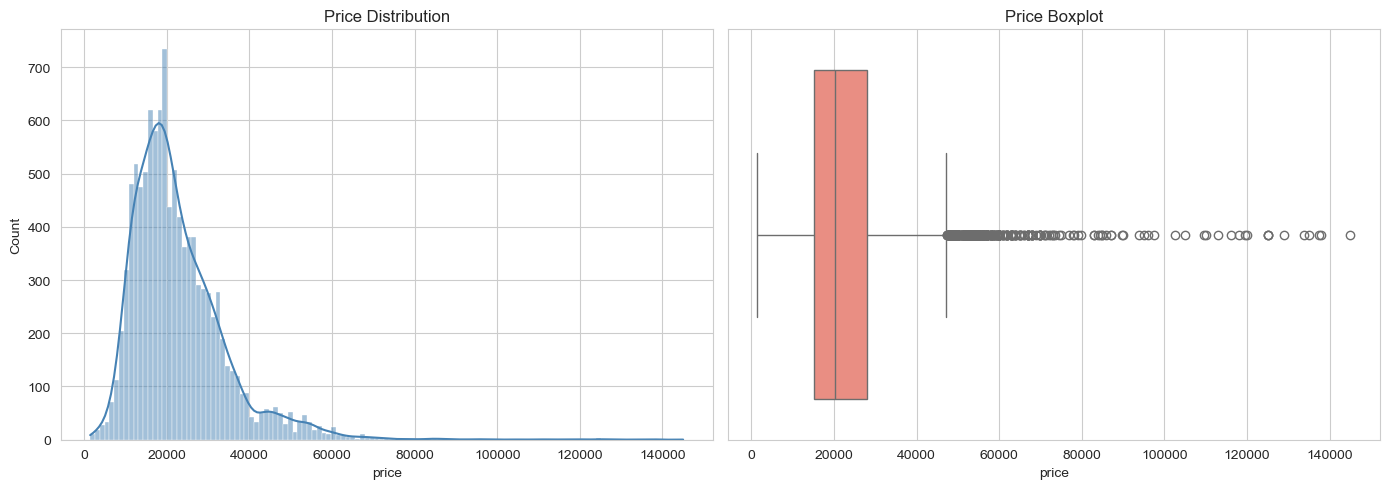

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['price'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Price Distribution')
sns.boxplot(x=df['price'], ax=axes[1], color='salmon')
axes[1].set_title('Price Boxplot')
plt.tight_layout()
plt.show()

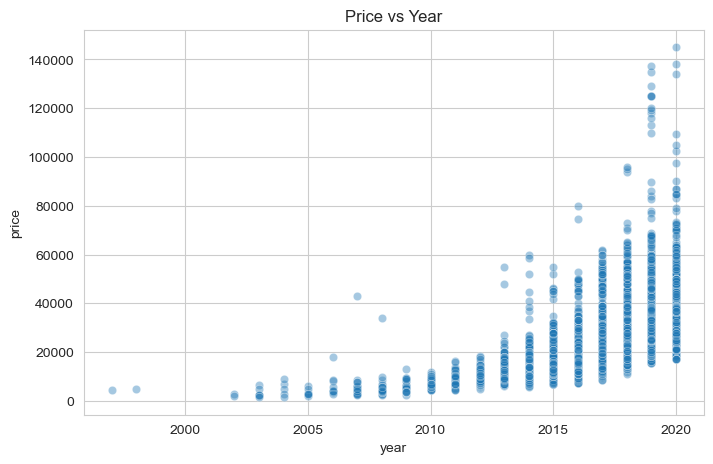

In [8]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='year', y='price', alpha=0.4)
plt.title('Price vs Year')
plt.show()

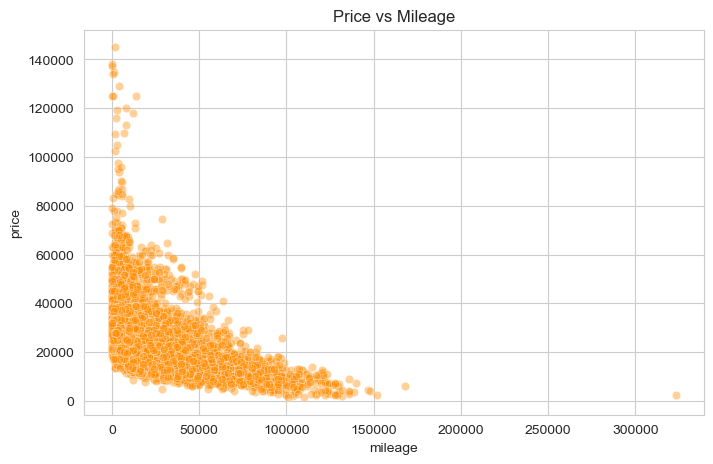

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='mileage', y='price', alpha=0.4, color='darkorange')
plt.title('Price vs Mileage')
plt.show()

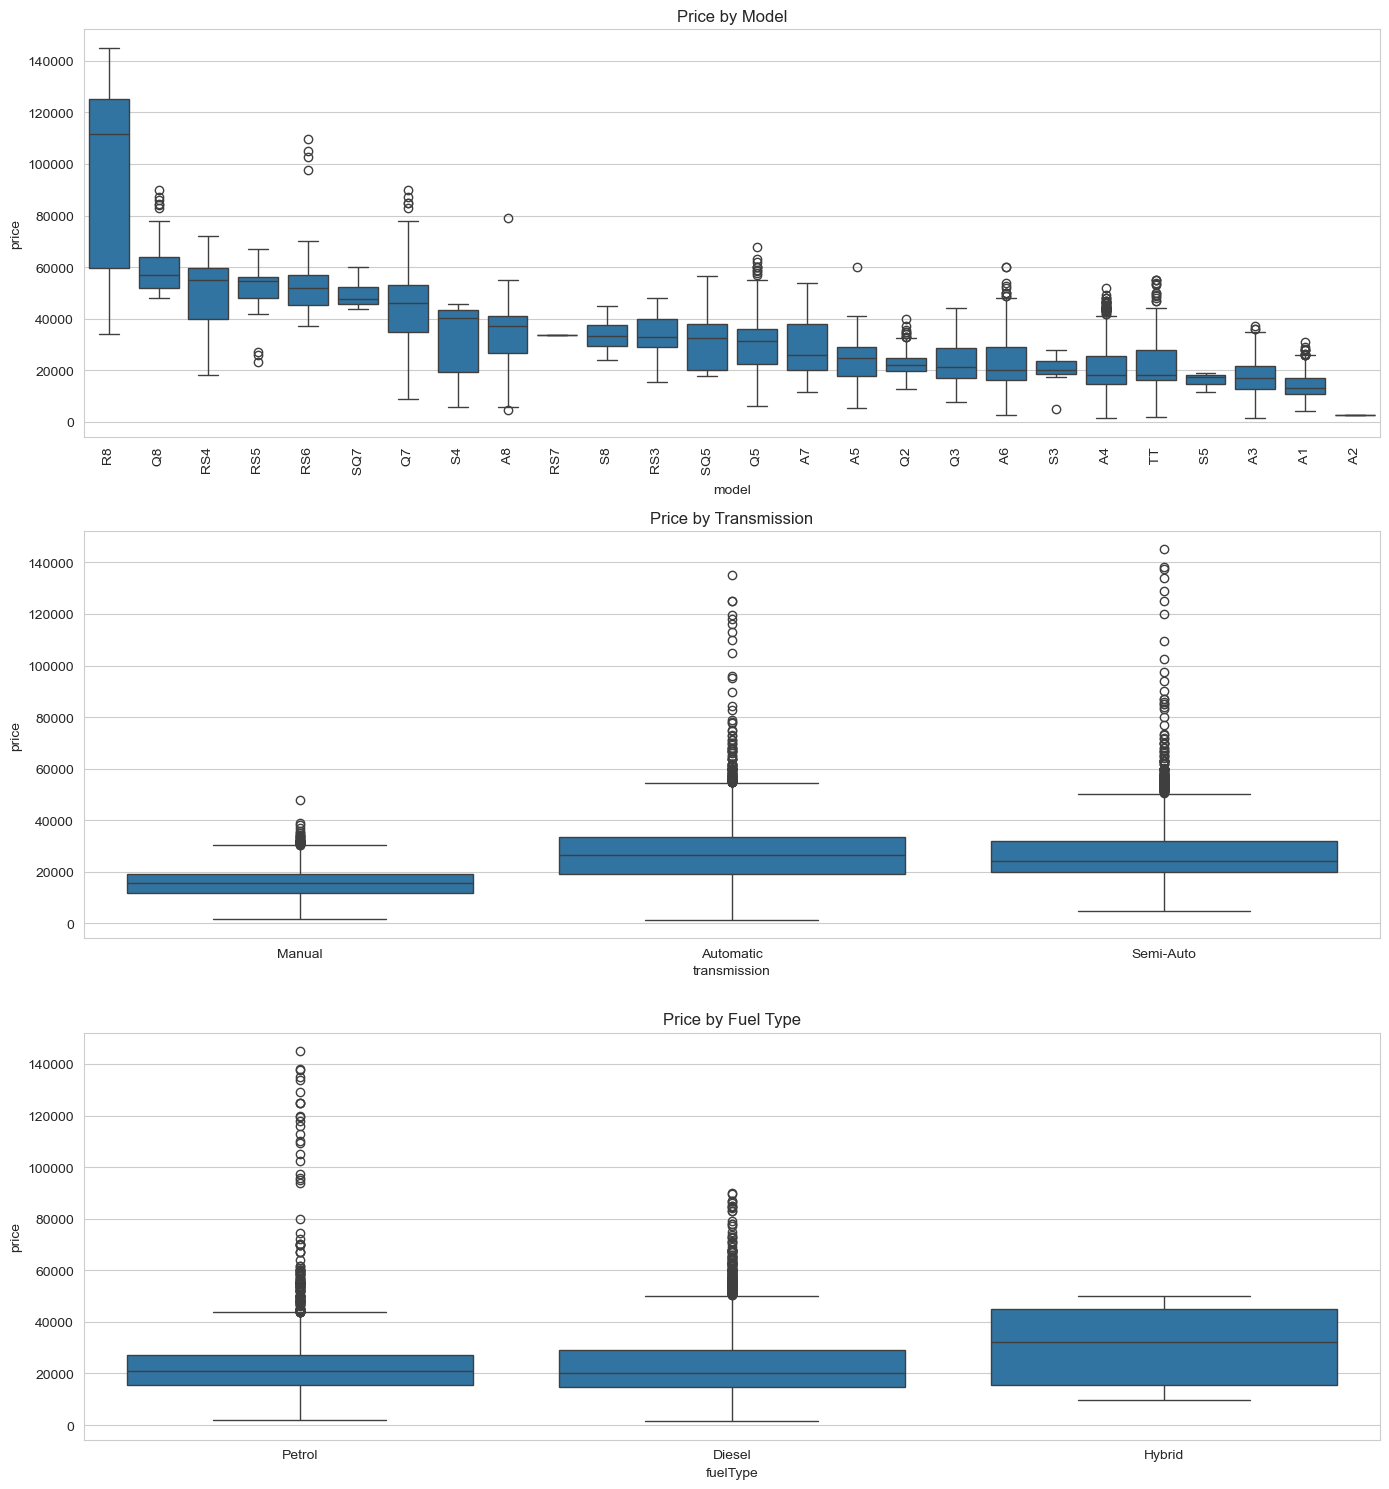

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 15))

order = df.groupby('model')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='model', y='price', order=order, ax=axes[0])
axes[0].set_title('Price by Model')
axes[0].tick_params(axis='x', rotation=90)

sns.boxplot(data=df, x='transmission', y='price', ax=axes[1])
axes[1].set_title('Price by Transmission')

sns.boxplot(data=df, x='fuelType', y='price', ax=axes[2])
axes[2].set_title('Price by Fuel Type')

plt.tight_layout()
plt.show()

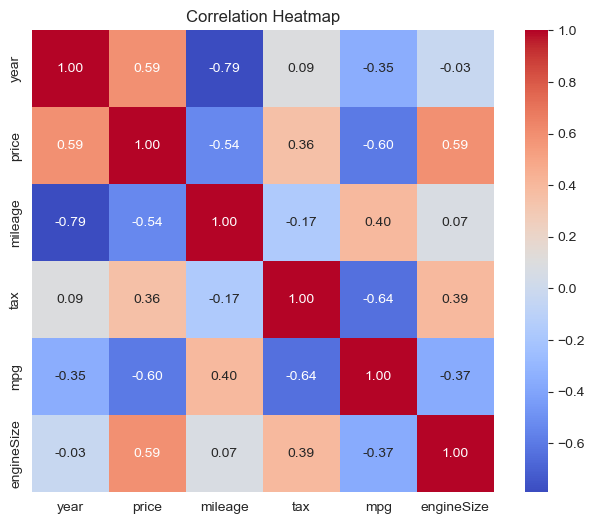

In [11]:
numeric_cols = ['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')
plt.show()

<font size="5">3. Preprocessing</font>


In [12]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0


In [13]:
X = df.iloc[:, [0, 1, 3, 4, 5, 6, 7, 8]].values 
Y = df.iloc[:, 2].values                        

print('X shape:', X.shape)
print('Y shape:', Y.shape)

X shape: (10668, 8)
Y shape: (10668,)


In [14]:
from sklearn.preprocessing import LabelEncoder

le_model = LabelEncoder()
X[:, 0] = le_model.fit_transform(X[:, 0])   

le_fuel = LabelEncoder()
X[:, 4] = le_fuel.fit_transform(X[:, 4])    

pd.DataFrame(X).head()

,0,1,2,3,4,5,6,7
0,0,2017,Manual,15735,2,150,55.4,1.4
1,5,2016,Automatic,36203,0,20,64.2,2.0
2,0,2016,Manual,29946,2,30,55.4,1.4
3,3,2017,Automatic,25952,0,145,67.3,2.0
4,2,2019,Manual,1998,2,145,49.6,1.0


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(), [2])],
    remainder='passthrough'
)
X = ct.fit_transform(X)
X = np.array(X, dtype=float)

print('X shape after one-hot encoding:', X.shape)
pd.DataFrame(X).head()

X shape after one-hot encoding: (10668, 10)


,0,1,2,3,4,5,6,7,8,9
0,0.0,1.0,0.0,0.0,2017.0,15735.0,2.0,150.0,55.4,1.4
1,1.0,0.0,0.0,5.0,2016.0,36203.0,0.0,20.0,64.2,2.0
2,0.0,1.0,0.0,0.0,2016.0,29946.0,2.0,30.0,55.4,1.4
3,1.0,0.0,0.0,3.0,2017.0,25952.0,0.0,145.0,67.3,2.0
4,0.0,1.0,0.0,2.0,2019.0,1998.0,2.0,145.0,49.6,1.0


In [16]:
# Here I performed Train/Test split.

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=0
)

print(X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)

(8534, 10) (2134, 10) (8534,) (2134,)


In [17]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)   
X_test_scaled = sc.transform(X_test)         

pd.DataFrame(X_train_scaled).head()

,0,1,2,3,4,5,6,7,8,9
0,-0.580868,1.198124,-0.713143,-1.127677,-0.047304,-0.235336,1.051292,-1.423664,0.433743,-0.882367
1,1.721561,-0.834638,-0.713143,0.431431,0.876486,-0.762394,1.051292,0.283192,-1.344849,0.118336
2,-0.580868,-0.834638,1.402243,-1.127677,-1.432991,-0.247022,1.051292,-0.013653,0.189473,-0.882367
3,-0.580868,1.198124,-0.713143,3.744536,-1.432991,0.111886,1.051292,2.064260,-1.146380,0.118336
4,1.721561,-0.834638,-0.713143,-0.737900,0.876486,-1.020590,-0.953787,0.283192,0.113138,-0.548799


<font size="5">4. Dimensionality Reduction</font>

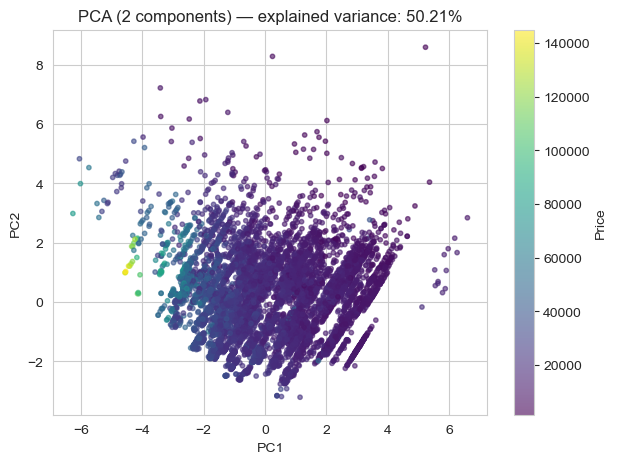

Explained variance ratio per component: [0.3114428 0.1906829]


In [18]:
# Using PCA

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(7, 5))
sc_plot = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=Y_train, cmap='viridis', s=10, alpha=0.6)
plt.colorbar(sc_plot, label='Price')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'PCA (2 components) — explained variance: {pca.explained_variance_ratio_.sum():.2%}')
plt.show()

print('Explained variance ratio per component:', pca.explained_variance_ratio_)

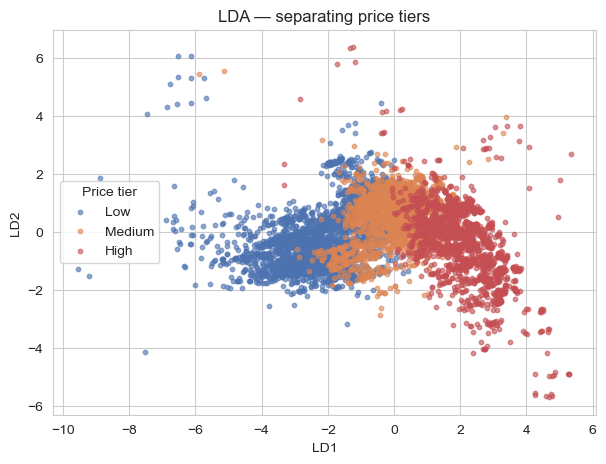

In [19]:
# Using LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

price_tier_train = pd.qcut(Y_train, q=3, labels=['Low', 'Medium', 'High'])

lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_train_scaled, price_tier_train)

plt.figure(figsize=(7, 5))
for tier, color in zip(['Low', 'Medium', 'High'], ['#4C72B0', '#DD8452', '#C44E52']):
    mask = (price_tier_train == tier)
    plt.scatter(X_lda[mask, 0], X_lda[mask, 1], label=tier, s=10, alpha=0.6, color=color)
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.title('LDA — separating price tiers')
plt.legend(title='Price tier')
plt.show()

<font size="5">5. Selecting the best algorithm</font>

In [20]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

results = {}

def evaluate(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    results[name] = {'R2': r2, 'MAE': mae, 'RMSE': rmse}
    print(f'{name:30s}  R2={r2:.4f}   MAE={mae:9.2f}   RMSE={rmse:9.2f}')

In [21]:
# Linear Regression
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, Y_train)
y_pred = lin_reg.predict(X_test_scaled)
evaluate('Linear Regression :', Y_test, y_pred)

Linear Regression :             R2=0.7916   MAE=  3381.67   RMSE=  5351.13


In [22]:
# Random Forest: with different parameters
from sklearn.ensemble import RandomForestRegressor

rf_100 = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=0)
rf_100.fit(X_train_scaled, Y_train)
y_pred = rf_100.predict(X_test_scaled)
evaluate('Random Forest (n=100 , depth = None) :', Y_test, y_pred)

rf_300 = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=0)
rf_300.fit(X_train_scaled, Y_train)
y_pred = rf_300.predict(X_test_scaled)
evaluate('Random Forest (n=300, depth=10) :', Y_test, y_pred)

Random Forest (n=100 , depth = None) :  R2=0.9536   MAE=  1538.57   RMSE=  2524.31
Random Forest (n=300, depth=10) :  R2=0.9498   MAE=  1653.42   RMSE=  2627.08


In [23]:
# Decision Tree Regressor: different parameters
from sklearn.tree import DecisionTreeRegressor

dt_shallow = DecisionTreeRegressor(max_depth=5, random_state=0)
dt_shallow.fit(X_train_scaled, Y_train)
y_pred = dt_shallow.predict(X_test_scaled)
evaluate('Decision Tree (depth=5) :', Y_test, y_pred)

dt_deep = DecisionTreeRegressor(max_depth=15, random_state=0)
dt_deep.fit(X_train_scaled, Y_train)
y_pred = dt_deep.predict(X_test_scaled)
evaluate('Decision Tree (depth=15) :', Y_test, y_pred)

Decision Tree (depth=5) :       R2=0.8273   MAE=  3008.39   RMSE=  4871.47
Decision Tree (depth=15) :      R2=0.8976   MAE=  1882.80   RMSE=  3751.92


In [24]:
# KNN Regressor: different parameters
from sklearn.neighbors import KNeighborsRegressor

knn_5 = KNeighborsRegressor(n_neighbors=5)
knn_5.fit(X_train_scaled, Y_train)
y_pred = knn_5.predict(X_test_scaled)
evaluate('KNN (k=5) :', Y_test, y_pred)

knn_10 = KNeighborsRegressor(n_neighbors=10, weights='distance')
knn_10.fit(X_train_scaled, Y_train)
y_pred = knn_10.predict(X_test_scaled)
evaluate('KNN (k=10, weights = distance) :', Y_test, y_pred)

KNN (k=5) :                     R2=0.9435   MAE=  1818.43   RMSE=  2786.94
KNN (k=10, weights = distance) :  R2=0.9477   MAE=  1758.76   RMSE=  2679.61


,R2,MAE,RMSE
"Random Forest (n=100 , depth = None) :",0.953629,1538.572766,2524.312779
"Random Forest (n=300, depth=10) :",0.949776,1653.424595,2627.079216
"KNN (k=10, weights = distance) :",0.947748,1758.762978,2679.607751
KNN (k=5) :,0.943478,1818.434677,2786.935710
Decision Tree (depth=15) :,0.897560,1882.801914,3751.923276
Decision Tree (depth=5) :,0.827304,3008.393763,4871.470772
Linear Regression :,0.791621,3381.673340,5351.126450


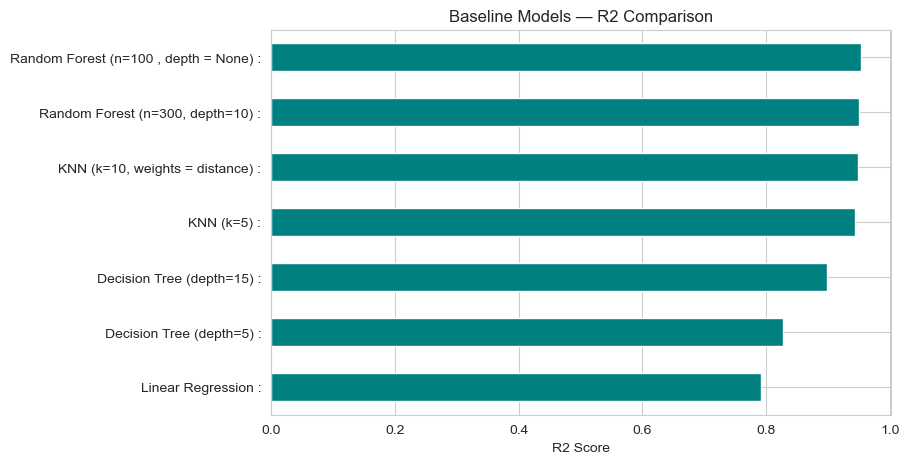

In [25]:
# Finally I compared all the models , and this is the result.
results_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)
display(results_df)

plt.figure(figsize=(8, 5))
results_df['R2'].sort_values().plot(kind='barh', color='teal')
plt.xlabel('R2 Score')
plt.title('Baseline Models — R2 Comparison')
plt.show()

Final statement : Random Forest delivers the strongest and most stable R² scores.

<font size="5">6. Boosting Algorithms</font>

In [26]:
# AdaBoost with different parameters
from sklearn.ensemble import AdaBoostRegressor

ada_50 = AdaBoostRegressor(n_estimators=50, learning_rate=1.0, random_state=0)
ada_50.fit(X_train_scaled, Y_train)
y_pred = ada_50.predict(X_test_scaled)
evaluate('AdaBoost (n=50)', Y_test, y_pred)

ada_200 = AdaBoostRegressor(n_estimators=200, learning_rate=0.5, random_state=0)
ada_200.fit(X_train_scaled, Y_train)
y_pred = ada_200.predict(X_test_scaled)
evaluate('AdaBoost (n=200, lr=0.5)', Y_test, y_pred)

AdaBoost (n=50)                 R2=0.7268   MAE=  5048.93   RMSE=  6127.25
AdaBoost (n=200, lr=0.5)        R2=0.6822   MAE=  5628.66   RMSE=  6608.80


In [27]:
# XGBoost with different parameters
from xgboost import XGBRegressor

xgb_a = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=0)
xgb_a.fit(X_train_scaled, Y_train)
y_pred = xgb_a.predict(X_test_scaled)
evaluate('XGBoost (n=200, depth=4, lr=0.1)', Y_test, y_pred)

xgb_b = XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.01, random_state=0)
xgb_b.fit(X_train_scaled, Y_train)
y_pred = xgb_b.predict(X_test_scaled)
evaluate('XGBoost (n=500, depth=6, lr=0.01)', Y_test, y_pred)

XGBoost (n=200, depth=4, lr=0.1)  R2=0.9584   MAE=  1589.08   RMSE=  2391.69
XGBoost (n=500, depth=6, lr=0.01)  R2=0.9584   MAE=  1606.96   RMSE=  2390.27


,R2,MAE,RMSE
"XGBoost (n=500, depth=6, lr=0.01)",0.958423,1606.955566,2390.266512
"XGBoost (n=200, depth=4, lr=0.1)",0.958373,1589.078125,2391.685494
AdaBoost (n=50),0.726792,5048.933062,6127.252263
"AdaBoost (n=200, lr=0.5)",0.682161,5628.660416,6608.797635


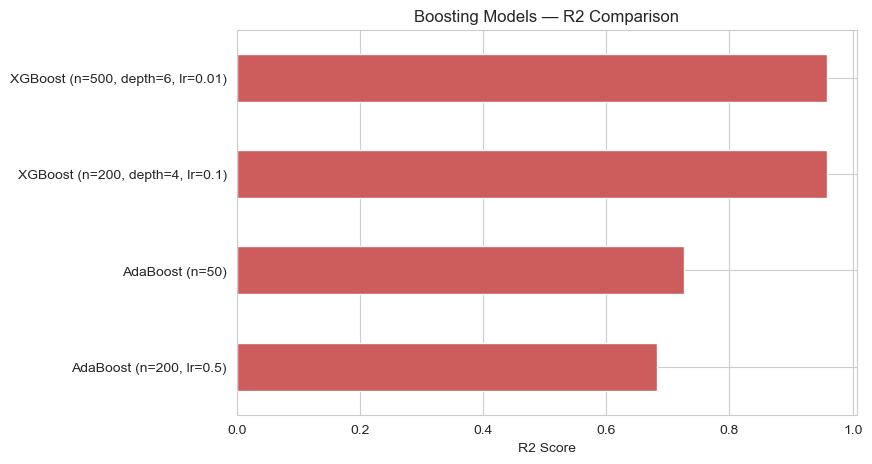

In [28]:
# Comparing the boosting techniques
boosting_results = pd.DataFrame(results).T.loc[
    ['AdaBoost (n=50)', 'AdaBoost (n=200, lr=0.5)',
     'XGBoost (n=200, depth=4, lr=0.1)', 'XGBoost (n=500, depth=6, lr=0.01)']
].sort_values('R2', ascending=False)
display(boosting_results)

plt.figure(figsize=(8, 5))
boosting_results['R2'].sort_values().plot(kind='barh', color='indianred')
plt.xlabel('R2 Score')
plt.title('Boosting Models — R2 Comparison')
plt.show()

Final Statement - XGBoost outperforms AdaBoost across both parameters.

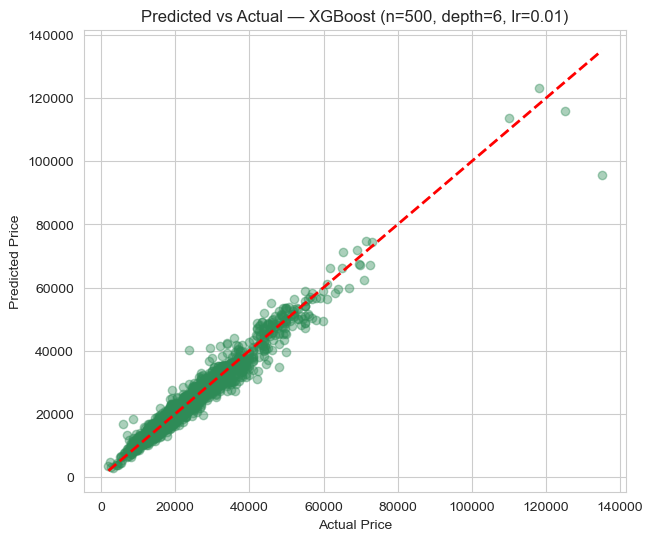

In [29]:
# Comparing Predicted vs Actual to decide the best boosting model 
best_boost_name = boosting_results['R2'].idxmax()
best_boost_model = {'AdaBoost (n=50)': ada_50, 'AdaBoost (n=200, lr=0.5)': ada_200,
                     'XGBoost (n=200, depth=4, lr=0.1)': xgb_a,
                     'XGBoost (n=500, depth=6, lr=0.01)': xgb_b}[best_boost_name]

y_pred_best = best_boost_model.predict(X_test_scaled)

plt.figure(figsize=(7, 6))
plt.scatter(Y_test, y_pred_best, alpha=0.4, color='seagreen')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Predicted vs Actual — {best_boost_name}')
plt.show()

Final Statement -The model is very accurate for typical cars but less precise on rare high-end trims.

<font size="5">7. Cross Validation</font>

In [30]:
from sklearn.model_selection import cross_val_score
X_full_scaled = sc.fit_transform(X)

cv_models = {
    'Linear Regression': LinearRegression(),
    'Random Forest (n=300, depth=10)': RandomForestRegressor(n_estimators=300, max_depth=10, random_state=0),
    'Decision Tree (depth=15)': DecisionTreeRegressor(max_depth=15, random_state=0),
    'KNN (k=10, weighted)': KNeighborsRegressor(n_neighbors=10, weights='distance'),
    'AdaBoost (n=200, lr=0.5)': AdaBoostRegressor(n_estimators=200, learning_rate=0.5, random_state=0),
    'XGBoost (n=500, depth=6, lr=0.01)': XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.01, random_state=0),
}

cv_results = {}
for name, model in cv_models.items():
    scores = cross_val_score(model, X_full_scaled, Y, cv=5, scoring='r2', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:35s}  mean R2={scores.mean():.4f}   std={scores.std():.4f}')

Linear Regression                    mean R2=0.7616   std=0.0393
Random Forest (n=300, depth=10)      mean R2=0.9444   std=0.0074
Decision Tree (depth=15)             mean R2=0.9244   std=0.0077
KNN (k=10, weighted)                 mean R2=0.9315   std=0.0154
AdaBoost (n=200, lr=0.5)             mean R2=0.6362   std=0.0681
XGBoost (n=500, depth=6, lr=0.01)    mean R2=0.9493   std=0.0043


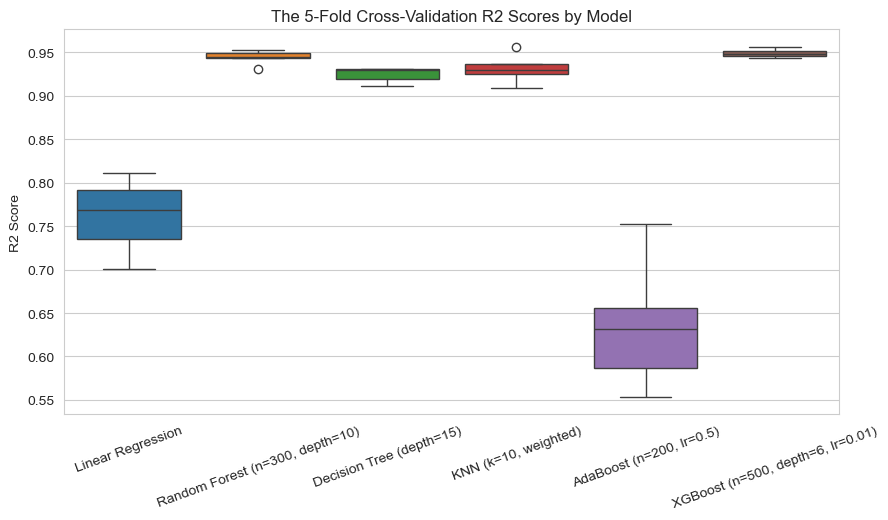

In [31]:
# The boxplot of CV scores across models
cv_df = pd.DataFrame(cv_results)

plt.figure(figsize=(10, 5))
sns.boxplot(data=cv_df)
plt.title('The 5-Fold Cross-Validation R2 Scores by Model')
plt.ylabel('R2 Score')
plt.xticks(rotation=20)
plt.show()

Final Statement - XGBoost is selected as the final model because it had the highest mean cross-validation R² of 0.94 with a low standard deviation of 0.0043.

<font size="5">8. Final Comparison and Prediction</font>

In [32]:
final_results_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)

cv_mean = {name: scores.mean() for name, scores in cv_results.items()}
cv_std = {name: scores.std() for name, scores in cv_results.items()}

final_results_df['CV_Mean_R2'] = final_results_df.index.map(cv_mean)
final_results_df['CV_Std_R2'] = final_results_df.index.map(cv_std)

display(final_results_df)

,R2,MAE,RMSE,CV_Mean_R2,CV_Std_R2
"XGBoost (n=500, depth=6, lr=0.01)",0.958423,1606.955566,2390.266512,0.949316,0.004259
"XGBoost (n=200, depth=4, lr=0.1)",0.958373,1589.078125,2391.685494,NaN,NaN
"Random Forest (n=100 , depth = None) :",0.953629,1538.572766,2524.312779,NaN,NaN
"Random Forest (n=300, depth=10) :",0.949776,1653.424595,2627.079216,NaN,NaN
"KNN (k=10, weights = distance) :",0.947748,1758.762978,2679.607751,NaN,NaN
KNN (k=5) :,0.943478,1818.434677,2786.935710,NaN,NaN
Decision Tree (depth=15) :,0.897560,1882.801914,3751.923276,NaN,NaN
Decision Tree (depth=5) :,0.827304,3008.393763,4871.470772,NaN,NaN
Linear Regression :,0.791621,3381.673340,5351.126450,NaN,NaN
AdaBoost (n=50),0.726792,5048.933062,6127.252263,NaN,NaN


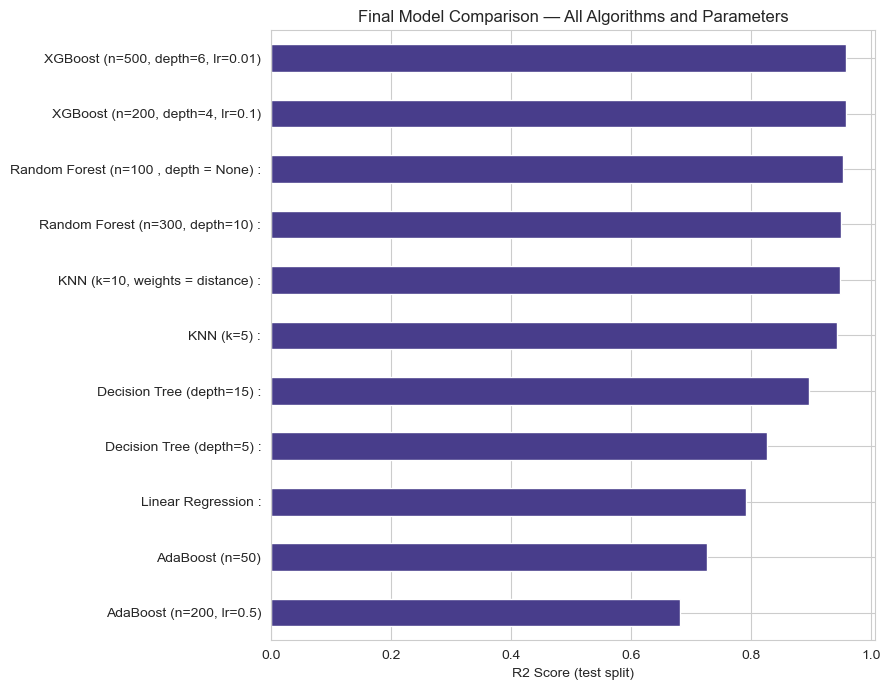

In [33]:
plt.figure(figsize=(9, 7))
final_results_df['R2'].sort_values().plot(kind='barh', color='darkslateblue')
plt.xlabel('R2 Score (test split)')
plt.title('Final Model Comparison — All Algorithms and Parameters')
plt.tight_layout()
plt.show()

In [34]:
# Here I selected the best model
best_model_name = final_results_df['R2'].idxmax()
print('Best model selected:', best_model_name)

model_lookup = {
    'Linear Regression': lin_reg,
    'Random Forest (n=100)': rf_100,
    'Random Forest (n=300, depth=10)': rf_300,
    'Decision Tree (depth=5)': dt_shallow,
    'Decision Tree (depth=15)': dt_deep,
    'KNN (k=5)': knn_5,
    'KNN (k=10, weighted)': knn_10,
    'AdaBoost (n=50)': ada_50,
    'AdaBoost (n=200, lr=0.5)': ada_200,
    'XGBoost (n=200, depth=4, lr=0.1)': xgb_a,
    'XGBoost (n=500, depth=6, lr=0.01)': xgb_b,
}
best_model = model_lookup[best_model_name]

best_model.fit(X_full_scaled, Y)

Best model selected: XGBoost (n=500, depth=6, lr=0.01)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [35]:
# Here I predicted on full dataset to show actual vs predicted 
full_pred = best_model.predict(X_full_scaled)

print('Final R2 on full data :', r2_score(Y, full_pred))
print('Final MAE on full data:', mean_absolute_error(Y, full_pred))

result = df.copy()
result['Price Prediction'] = full_pred
result.head(10)

Final R2 on full data : 0.9689887166023254
Final MAE on full data: 1467.546630859375


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Price Prediction
0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4,13971.976562
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,16843.191406
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,12575.543945
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,19058.337891
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,19162.492188
5,A1,2016,13900,Automatic,32260,Petrol,30,58.9,1.4,14024.791992
6,A6,2016,13250,Automatic,76788,Diesel,30,61.4,2.0,14491.385742
7,A4,2016,11750,Manual,75185,Diesel,20,70.6,2.0,12019.725586
8,A3,2015,10200,Manual,46112,Petrol,20,60.1,1.4,11784.749023
9,A1,2016,12000,Manual,22451,Petrol,30,55.4,1.4,13040.175781


In [36]:
import pickle
with open('model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

In [39]:
with open('preprocessing.pkl', 'wb') as f:
    pickle.dump({
        'label_encoder_model': le_model,
        'label_encoder_fuel': le_fuel,
        'column_transformer': ct,
        'scaler': sc,
    }, f)

<font size="5">9. Conclusion : Across 11 model/parameter combinations spanning Linear Regression, Decision Tree, Random Forest, KNN, AdaBoost, and XGBoost, XGBoostRegresser achieved the best test-set R² and was confirmed stable with 5-fold cross-validation (mean R² = 0.94, standard deviation = 0.0043 ).</font>